In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
from ydata_profiling import ProfileReport
import numpy as np

In [2]:
df = pd.read_csv('Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isna().sum()

CustomerID                 0
Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

In [5]:
df.nunique()

CustomerID                2000
Gender                       2
Age                        100
Annual Income ($)         1786
Spending Score (1-100)     101
Profession                   9
Work Experience             18
Family Size                  9
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              2000 non-null   int64 
 1   Gender                  2000 non-null   object
 2   Age                     2000 non-null   int64 
 3   Annual Income ($)       2000 non-null   int64 
 4   Spending Score (1-100)  2000 non-null   int64 
 5   Profession              1965 non-null   object
 6   Work Experience         2000 non-null   int64 
 7   Family Size             2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB


In [7]:
df[df['Profession'].isna() == True]

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
79,80,Female,49,98000,42,NaN,1,1
118,119,Female,51,84000,43,NaN,2,7
219,220,Female,59,76000,61,NaN,9,1
237,238,Male,95,36000,35,NaN,0,4
437,438,Male,76,136259,14,NaN,0,7
440,441,Female,0,57373,29,NaN,0,7
498,499,Male,95,121725,3,NaN,12,3
545,546,Female,89,107359,26,NaN,10,6
601,602,Male,61,126370,20,NaN,11,4
641,642,Male,66,121377,19,NaN,7,7


<Axes: xlabel='Age', ylabel='Count'>

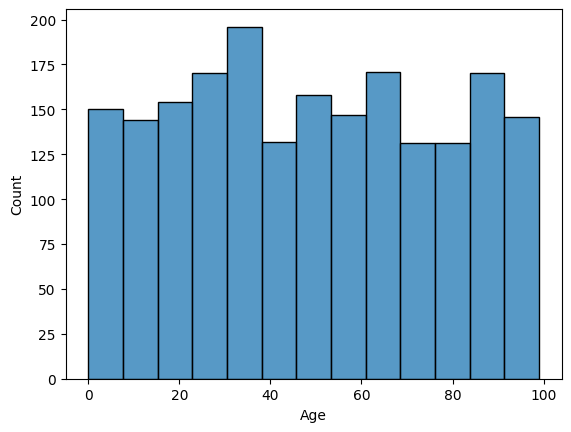

In [8]:
sns.histplot(data=df, x='Age')

In [9]:
df['Work Experience'].value_counts().sort_index()

Work Experience
0     431
1     470
2      63
3      55
4     121
5     117
6     120
7     126
8     166
9     160
10     84
11     14
12     17
13     16
14     16
15     14
16      5
17      5
Name: count, dtype: int64

In [10]:
entry_age_map = {
    'Healthcare ': 25,
    'Engineer': 23,
    'Doctor': 25
}

def estimate_age(row):
    if row['Age'] <= 18:
        base_age = entry_age_map.get(row['Profession'], 22) 
        estimated = base_age + row['Work Experience'] + np.random.randint(-2, 3)
        return estimated
    return row['Age']

df['Age'] = df.apply(estimate_age, axis=1)

<Axes: xlabel='Age', ylabel='Count'>

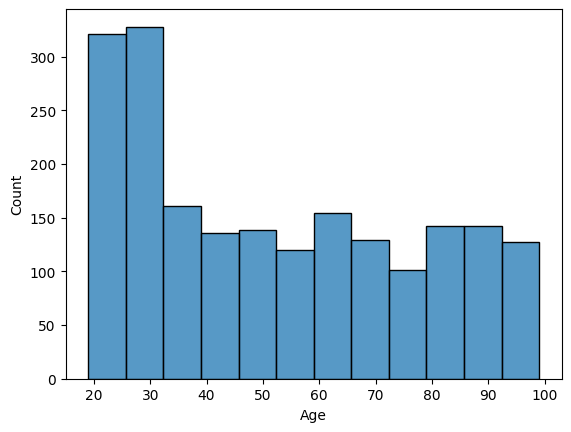

In [11]:
sns.histplot(data=df, x='Age')

In [12]:
df.Profession.value_counts()

Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
Name: count, dtype: int64

In [13]:
df.Gender.value_counts()

Gender
Female    1186
Male       814
Name: count, dtype: int64

In [14]:
df.Age.mean()

np.float64(52.139)

In [15]:
df['Annual Income ($)'].mean()

np.float64(110731.8215)

In [16]:
df['Annual Income ($)'].median()

np.float64(110045.0)

In [17]:
avg_income = df.groupby('Gender')['Annual Income ($)'].mean()
np.round(avg_income)

Gender
Female    110554.0
Male      110991.0
Name: Annual Income ($), dtype: float64

### 1. Distribution of Customer Professions

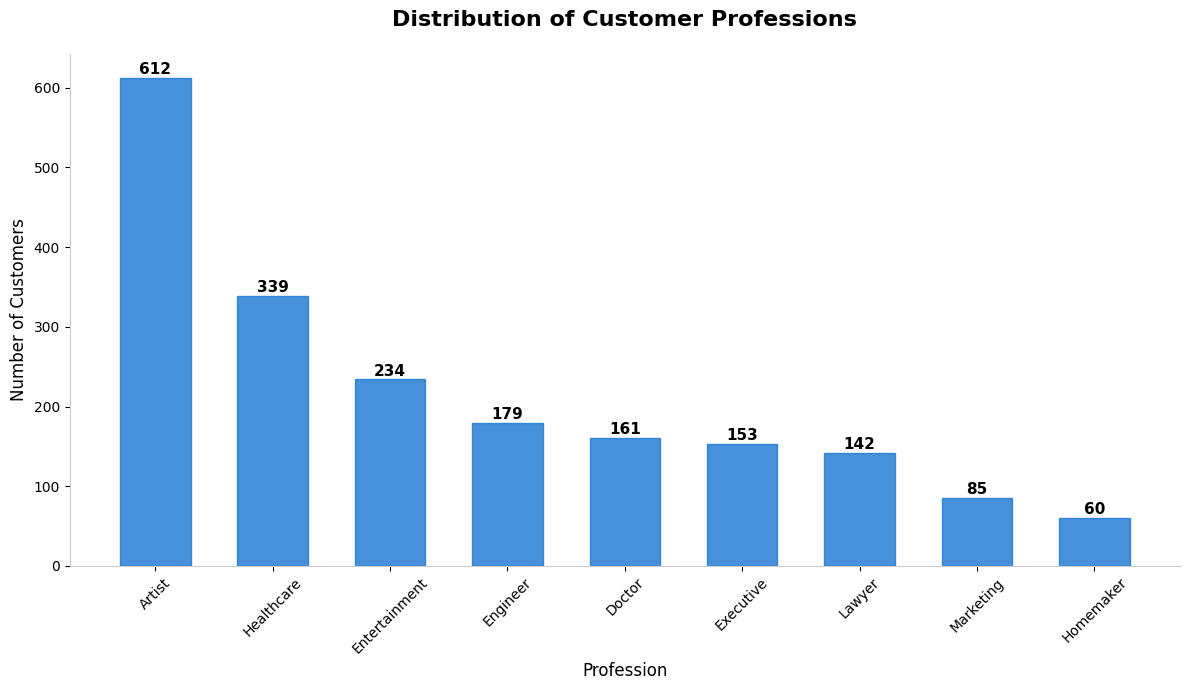

In [18]:
profession_counts = df.Profession.value_counts()
professions = profession_counts.index
counts = profession_counts.values

plt.figure(figsize=(12,7))
colors = color="#1976d2"
bars = plt.bar(professions, counts, color=colors, edgecolor=colors, alpha=0.8, width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribution of Customer Professions', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Profession', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=45)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

plt.grid(False)
plt.tight_layout()
plt.show()

### 2. Customer Gender Distribution

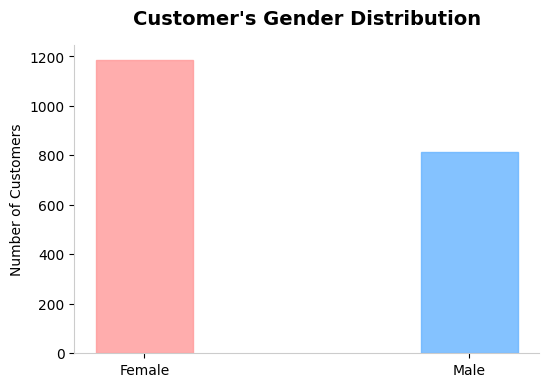

In [19]:
columns_title = {
    'Gender': 'Gendr Counts',
    'Family Size': 'Family Size Counts'
}

gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,4))
colors = ['#ff9999','#66b3ff']
plt.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor=colors, alpha=0.8, width=0.3)
plt.title("Customer's Gender Distribution", fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Customers')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

plt.grid(False)
plt.show()

### 3. Distribution of Family Sizes

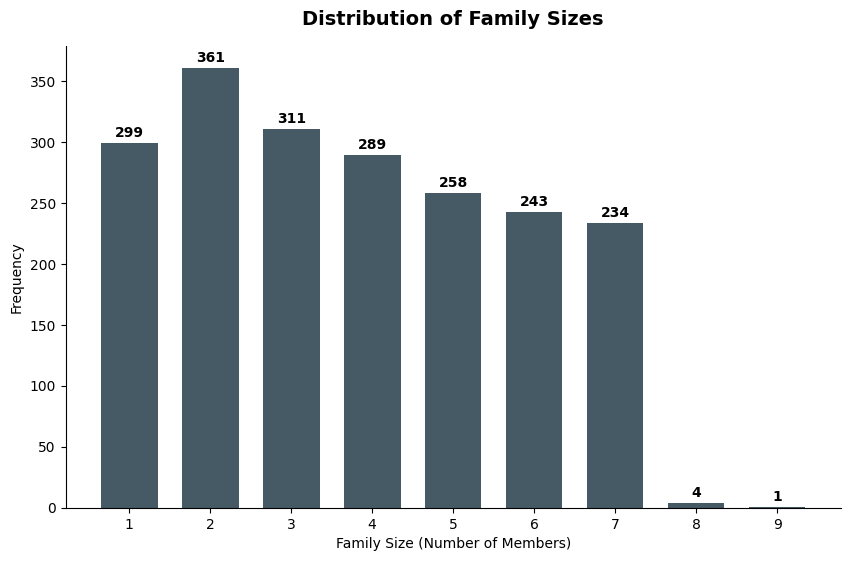

In [20]:
family_counts = df['Family Size'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(family_counts.index.astype(str), family_counts.values, width=0.7, color='#455a64')

for i, v in enumerate(family_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.title('Distribution of Family Sizes', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Family Size (Number of Members)')
plt.ylabel('Frequency')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(False)
plt.show()

### 4. Distribution of customers with Spending Score > 50 across different professions

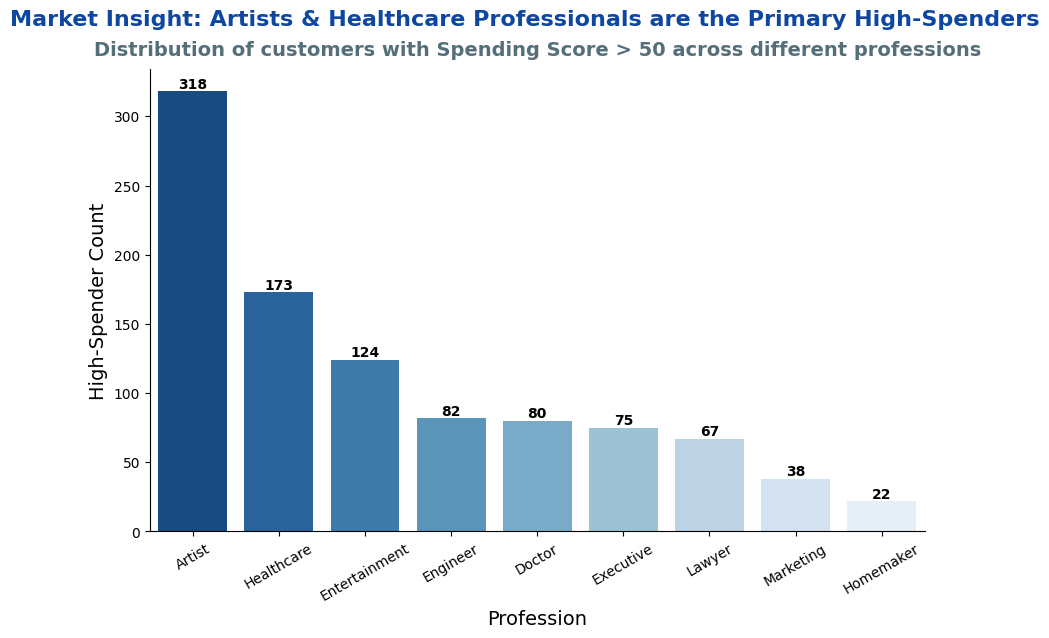

In [21]:
def plot_professions(ax, df, s, c):
    profession_data = df[df['Spending Score (1-100)'] > 50]['Profession'].value_counts()
    sns.barplot(x=profession_data.index, y=profession_data.values, palette="Blues_r",
                hue=profession_data.index, legend=False, ax=ax)
    ax.set_xlabel('Profession', fontsize=14)
    ax.set_ylabel('High-Spender Count', fontsize=14)
    ax.set_title('Distribution of customers with Spending Score > 50 across different professions',
                 fontsize=s, fontweight='bold',pad=10, color=c)
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    sns.despine()
    plt.grid(False)


fig, ax = plt.subplots(figsize=(10, 6))
plot_professions(ax, df, 14, '#546e7a')
plt.suptitle('Market Insight: Artists & Healthcare Professionals are the Primary High-Spenders', 
             fontsize=16, fontweight='bold', color='#0d47a1')
plt.show()

### 5. Count of families with Spending Score > 50 categorized by number of members

In [22]:
df['Family Size Grouped'] = df['Family Size'].astype(str)

df['Family Size Grouped'] = df['Family Size Grouped'].replace(['7', '8', '9'], '7+')

logical_order = ['1', '2', '3', '4', '5', '6', '7+']
df['Family Size Grouped'] = pd.Categorical(df['Family Size Grouped'], categories=logical_order, ordered=True)
df.sample(2)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Family Size Grouped
329,330,Female,78,98922,2,Artist,2,3,3
1337,1338,Male,31,60933,30,Doctor,8,1,1


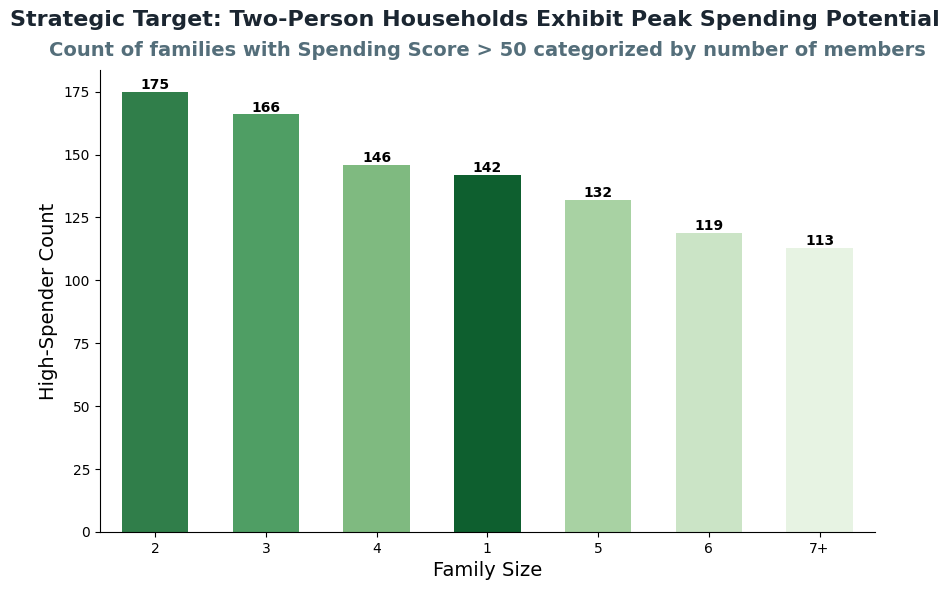

In [23]:
def plot_family_size(ax, df, s, c):
    high_scores_family_data = df[df['Spending Score (1-100)'] > 50]['Family Size Grouped'].value_counts()
    sns.barplot(x=high_scores_family_data.index.astype(str), y=high_scores_family_data.values,
                width=0.6,
                palette='Greens_r',
               hue=high_scores_family_data.index,
               legend=False,
               ax=ax)
    for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title('Count of families with Spending Score > 50 categorized by number of members', 
              fontsize=s,fontweight='bold', pad=10, color=c)
    ax.set_xlabel('Family Size', fontsize=14)
    ax.set_ylabel('High-Spender Count', fontsize=14)
    sns.despine()
    plt.grid(False)

fig, ax = plt.subplots(figsize=(10, 6))
plot_family_size(ax, df, 14, '#546e7a')
plt.suptitle('Strategic Target: Two-Person Households Exhibit Peak Spending Potential', 
                 fontsize=16, fontweight='bold', color='#1b2631')
plt.show()

### 6. Correlation analysis between annual household income and individual spending scores

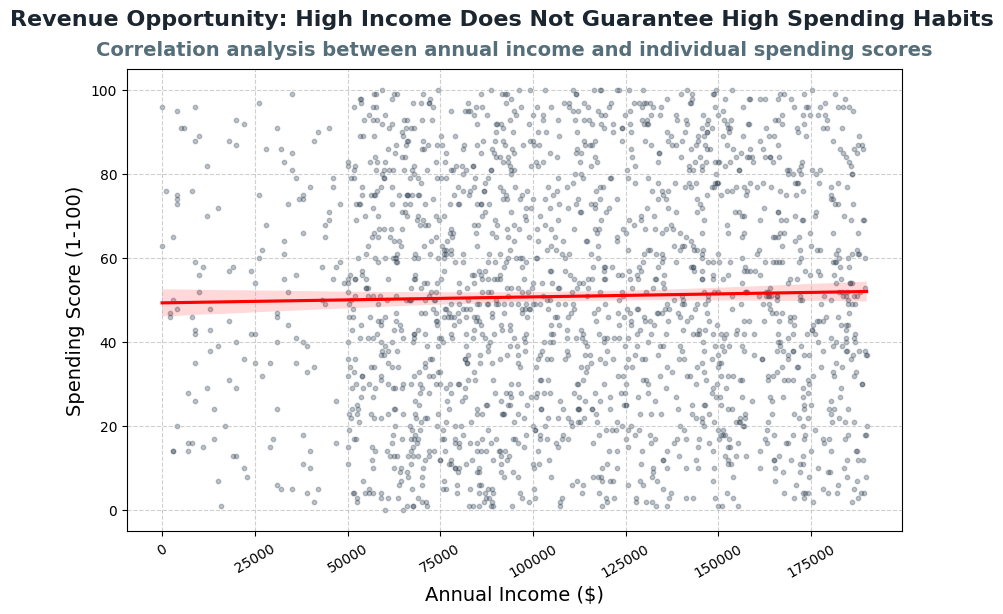

In [24]:
def plot_corr_analysis(ax, df, s, c):
    sns.regplot(data=df, x='Annual Income ($)', y='Spending Score (1-100)', 
            scatter_kws={'alpha':0.3, 'color':'#2c3e50', 's':10},
            line_kws={'color':'red', 'label':'Linear Trend'})    
    ax.set_title("Correlation analysis between annual income and individual spending scores", 
              fontsize=s, fontweight='bold',pad=10, color=c)
    ax.set_xlabel('Annual Income ($)', fontsize=14)
    ax.set_ylabel('Spending Score (1-100)', fontsize=14)
    ax.tick_params(axis='x', rotation=30)
    plt.grid(True, linestyle='--', alpha=0.6)


fig, ax = plt.subplots(figsize=(10, 6))
plot_corr_analysis(ax, df, 14, '#546e7a')
plt.suptitle('Revenue Opportunity: High Income Does Not Guarantee High Spending Habits', 
                 fontsize=16, fontweight='bold', color='#1b2631')
plt.show()

### 7. Comprehensive Analysis: Income vs Spending

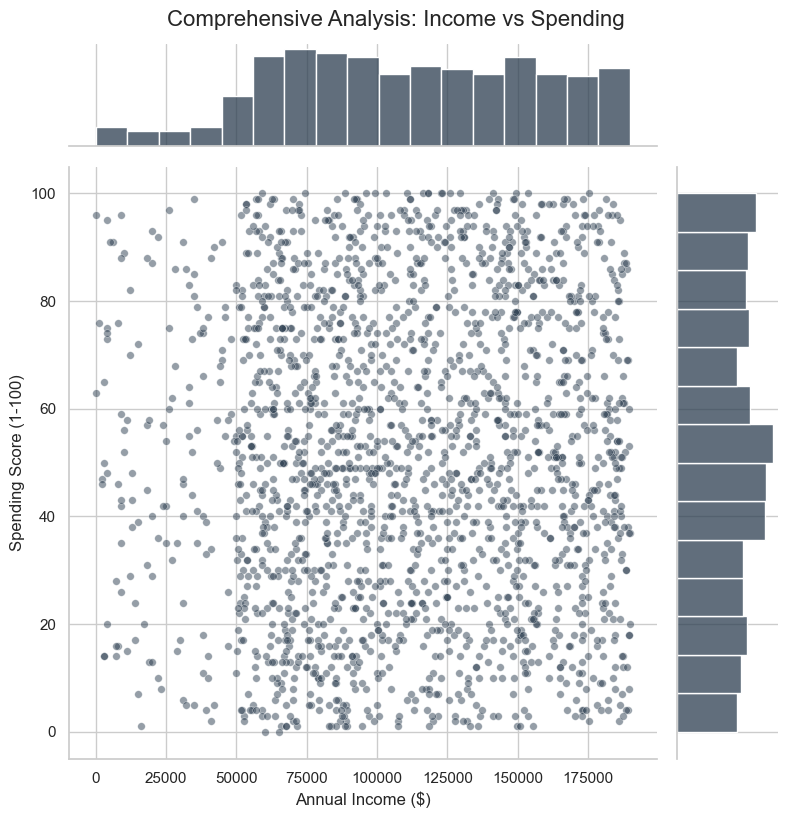

In [25]:
sns.set_theme(style="whitegrid")
g = sns.jointplot(
    data=df, 
    x='Annual Income ($)', 
    y='Spending Score (1-100)',
    kind='scatter',
    alpha=0.5,      
    s=30,           
    color="#2c3e50", 
    height=8        
)


g.fig.suptitle('Comprehensive Analysis: Income vs Spending', y=1.02, fontsize=16)
g.set_axis_labels('Annual Income ($)', 'Spending Score (1-100)', fontsize=12)

plt.show()

### 8. Demographic distribution of customers by age group and gender classification

In [26]:
bins = [18, 29, 39, 49, 59, 69, 79, 100]

labels = ['19-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80 and Above']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

In [27]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Family Size Grouped,Age Group
412,413,Female,65,86509,88,Artist,0,4,4,60-69
652,653,Female,28,189072,86,Artist,6,3,3,19-29
1282,1283,Male,31,175208,43,Executive,8,4,4,30-39
416,417,Female,86,187667,12,Artist,0,1,1,80 and Above
622,623,Female,56,91180,61,Entertainment,1,7,7+,50-59


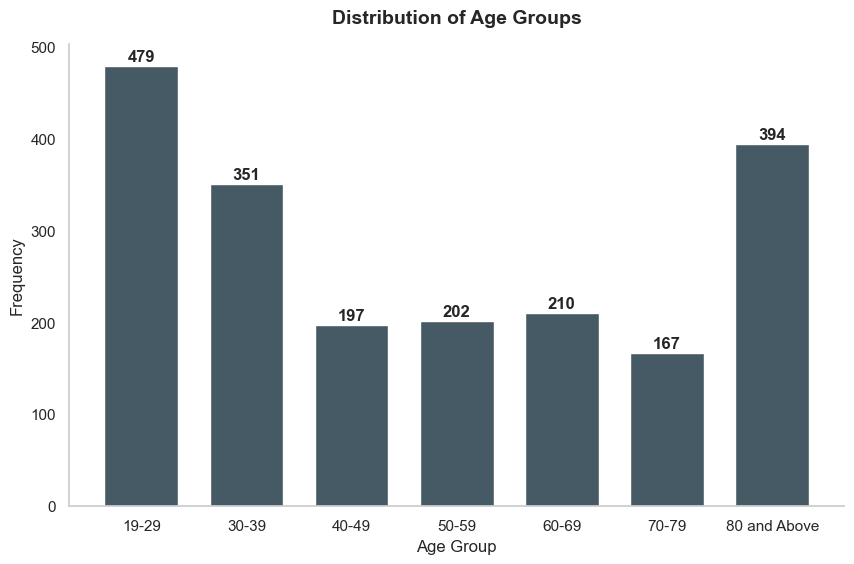

In [28]:
agegroup_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(agegroup_counts.index, agegroup_counts.values, width=0.7, color='#455a64')

for i, v in enumerate(agegroup_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.title('Distribution of Age Groups', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Age Group')
plt.ylabel('Frequency')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(False)
plt.show()

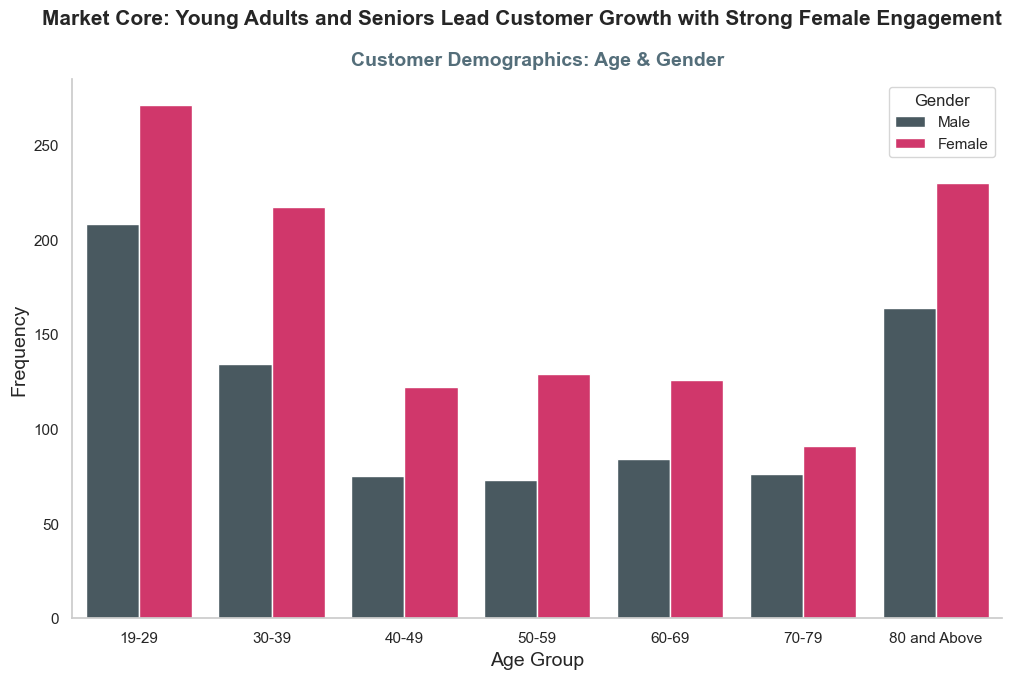

In [29]:
def plot_demographics(ax, df, s, c):
    custom_palette = {"Male": "#455a64", "Female": "#e91e63"}
    sns.countplot(data=df, x=df['Age Group'], hue=df['Gender'],
                  palette=custom_palette, ax=ax)
    ax.set_title('Customer Demographics: Age & Gender', 
                 fontsize=s, fontweight='bold', pad=10, color=c)
    ax.set_xlabel('Age Group', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.legend(title='Gender', loc='upper right')
    sns.despine()
    plt.grid(False)


fig, ax = plt.subplots(figsize=(12, 7))
plot_demographics(ax, df, 14, '#546e7a')
plt.suptitle('Market Core: Young Adults and Seniors Lead Customer Growth with Strong Female Engagement', 
             fontsize=15, fontweight='bold')
plt.show()

### 9. Average spending scores segmented by career experience levels

In [30]:
bins = [0, 5, 10, 15, 20]
labels = ['Junior (0-5)', 'Mid-Level (6-10)', 'Senior (11-15)', 'Expert (16+)']
df['Experience Level'] = pd.cut(df['Work Experience'], bins=bins, labels=labels, include_lowest=True)
df.sample(3)

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Family Size Grouped,Age Group,Experience Level
331,332,Female,24,93713,62,Engineer,3,4,4,19-29,Junior (0-5)
637,638,Female,26,113707,97,Entertainment,0,5,5,19-29,Junior (0-5)
822,823,Male,26,180702,21,Entertainment,6,1,1,19-29,Mid-Level (6-10)


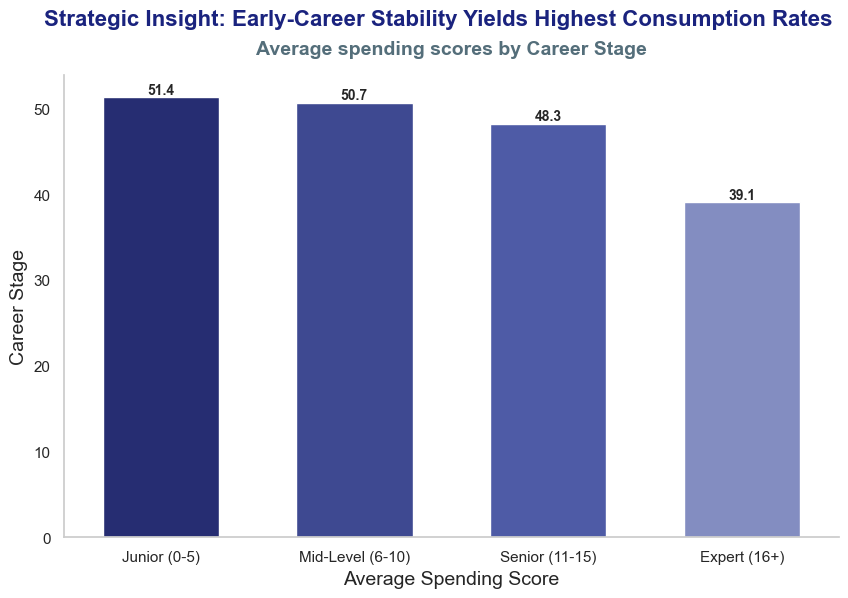

In [31]:
def plot_experience_spending(ax, df, s, c):
    exp_spending = df.groupby('Experience Level', observed=False)['Spending Score (1-100)'].mean()
    colors = ["#1a237e", "#303f9f", "#3f51b5", "#7986cb"]
    sns.barplot(x=exp_spending.index, y=exp_spending.values,
                hue=exp_spending.index, legend=False,
                   palette=colors, width=0.6, ax=ax)
    ax.set_title('Average spending scores by Career Stage', 
              fontsize=s, pad=15, fontweight='bold', color=c)
    ax.set_xlabel('Average Spending Score', fontsize=14)
    ax.set_ylabel('Career Stage', fontsize=14)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    sns.despine()
    plt.grid(False)


fig, ax = plt.subplots(figsize=(10, 6))
plot_experience_spending(ax, df, 14, '#546e7a')
plt.suptitle('Strategic Insight: Early-Career Stability Yields Highest Consumption Rates', 
                 fontsize=16, fontweight='bold', color='#1a237e', y=0.99)
plt.show()

### 10. Comparative analysis of annual income distribution across different professional categories

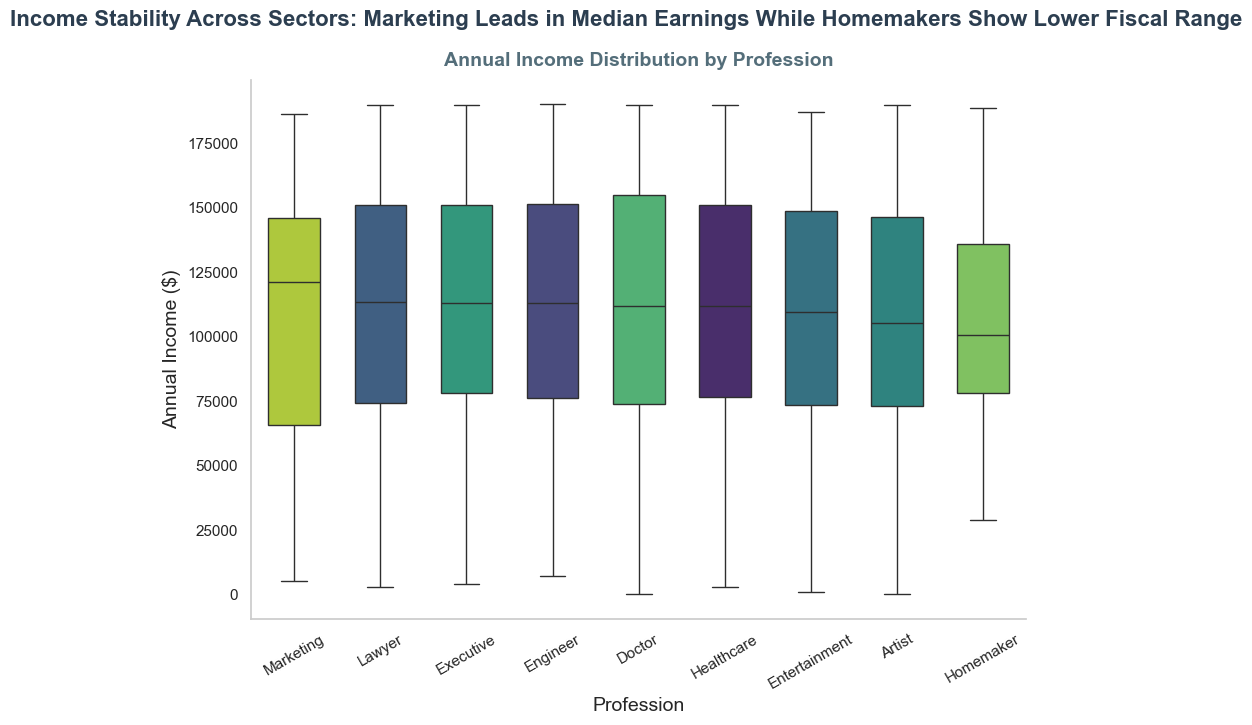

In [32]:
def plot_income_dist(ax, df, s, c):
    order = df.groupby('Profession')['Annual Income ($)'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='Profession', y='Annual Income ($)',
                width=0.6, order=order, hue='Profession',
                legend=False, palette="viridis", ax=ax)
    ax.set_title('Annual Income Distribution by Profession', 
              fontsize=s, pad=10, fontweight='bold',color=c)
    ax.set_xlabel('Profession', fontsize=14)
    ax.set_ylabel('Annual Income ($)', fontsize=14)
    ax.tick_params(axis='x', rotation=30)
    # plt.axhline(df['Annual Income ($)'].mean(), color='red', linestyle='--', alpha=0.7, label='Global Average Income')
    # plt.legend()
    sns.despine()
    plt.grid(False)

fig, ax = plt.subplots(figsize=(10, 7))
plot_income_dist(ax, df, 14, '#546e7a')
plt.suptitle('Income Stability Across Sectors: Marketing Leads in Median Earnings While Homemakers Show Lower Fiscal Range', 
                 fontsize=16, fontweight='bold', color='#2c3e50', y=0.98)
plt.show()

### 11. Comparison of the mean spending scores across different age demographics

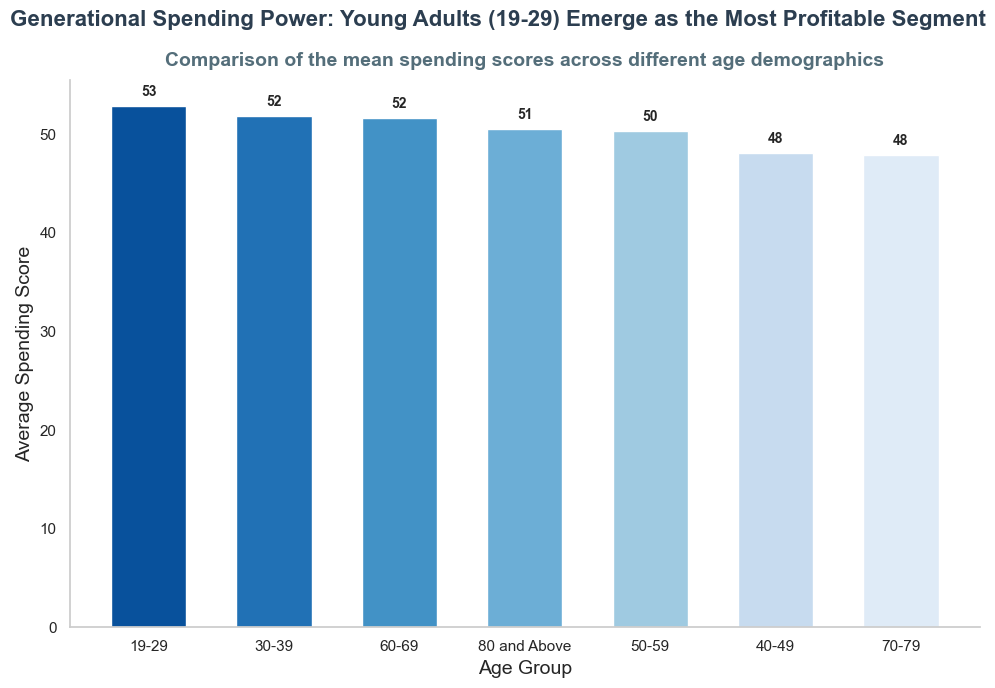

In [33]:
def plot_avg_spending(ax, df, s, c):
    age_spending = df.groupby('Age Group', observed=False)['Spending Score (1-100)']\
        .mean().sort_values(ascending=False)
    colors = sns.color_palette("Blues_r", len(age_spending))
    bars = ax.bar(age_spending.index, age_spending.values, color=colors, width=0.6)    
    ax.set_title('Comparison of the mean spending scores across different age demographics', 
              fontsize=s, pad=10, fontweight='bold',color=c)
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:,.0f}', 
                    (bar.get_x() + bar.get_width() / 2., height), 
                    ha='center', va='bottom', xytext=(0, 5), 
                    textcoords='offset points', fontsize=10, fontweight='bold')

    ax.set_xlabel('Age Group', fontsize=14)
    ax.set_ylabel('Average Spending Score', fontsize=14)
    sns.despine()
    plt.grid(False)


fig, ax = plt.subplots(figsize=(10, 7))
plot_avg_spending(ax, df, 14, '#546e7a')
plt.suptitle('Generational Spending Power: Young Adults (19-29) Emerge as the Most Profitable Segment', 
                 fontsize=16, fontweight='bold', color='#2c3e50', y=0.98)
plt.tight_layout()
plt.show()

### 12. Mean annual income per household size showing standard deviation

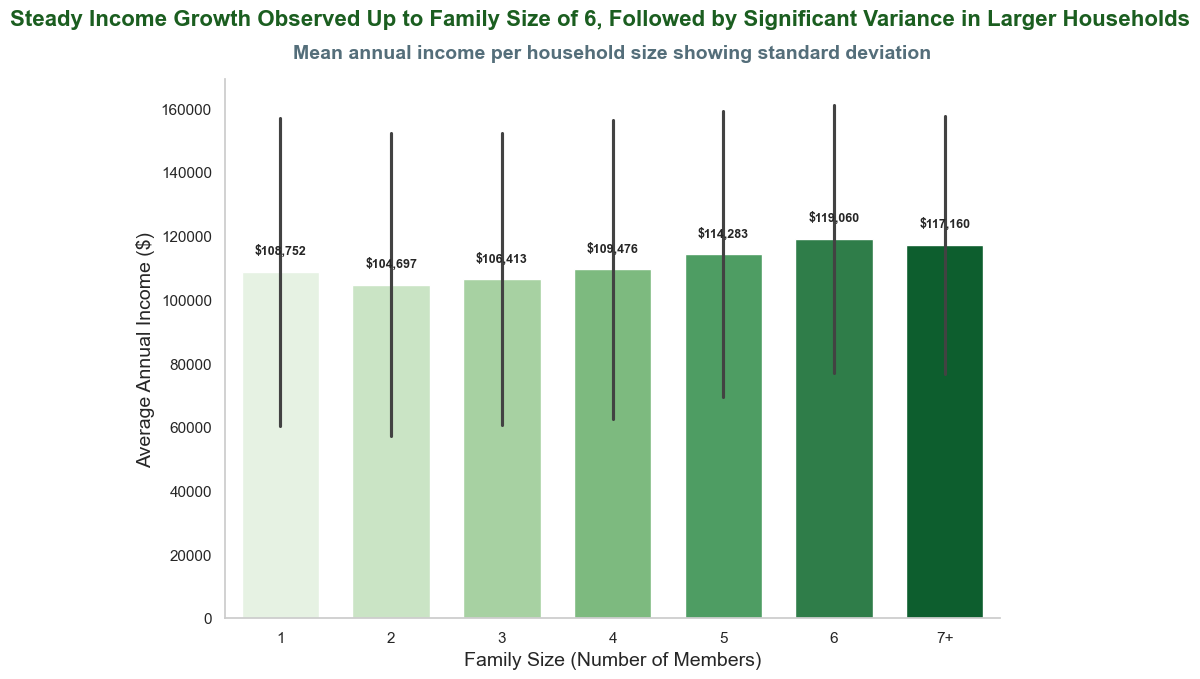

In [50]:
def plot_family_income_trend(ax, df, s, c):
    ax = sns.barplot(data=df,x='Family Size Grouped', y='Annual Income ($)', 
                     palette="Greens", errorbar='sd',
                     ax=ax, hue='Family Size Grouped',
                     legend=False, width=0.7)
    
    ax.set_title('Mean annual income per household size showing standard deviation', 
              fontsize=s, pad=15, fontweight='bold',color=c)
    ax.set_xlabel('Family Size (Number of Members)', fontsize=14)
    ax.set_ylabel('Average Annual Income ($)', fontsize=14)
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'${p.get_height():,.0f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 15), 
                        textcoords='offset points', fontsize=9, fontweight='bold')
    
    sns.despine(ax=ax)
    plt.grid(False)

fig, ax = plt.subplots(figsize=(10, 7))
plot_family_income_trend(ax, df, 14, '#546e7a')
plt.suptitle('Steady Income Growth Observed Up to Family Size of 6, Followed by Significant Variance in Larger Households', 
                 fontsize=16, fontweight='bold', color='#1b5e20', y=0.98)
plt.show()

### 13. Correlation matrix showing the relationship between key numerical variables

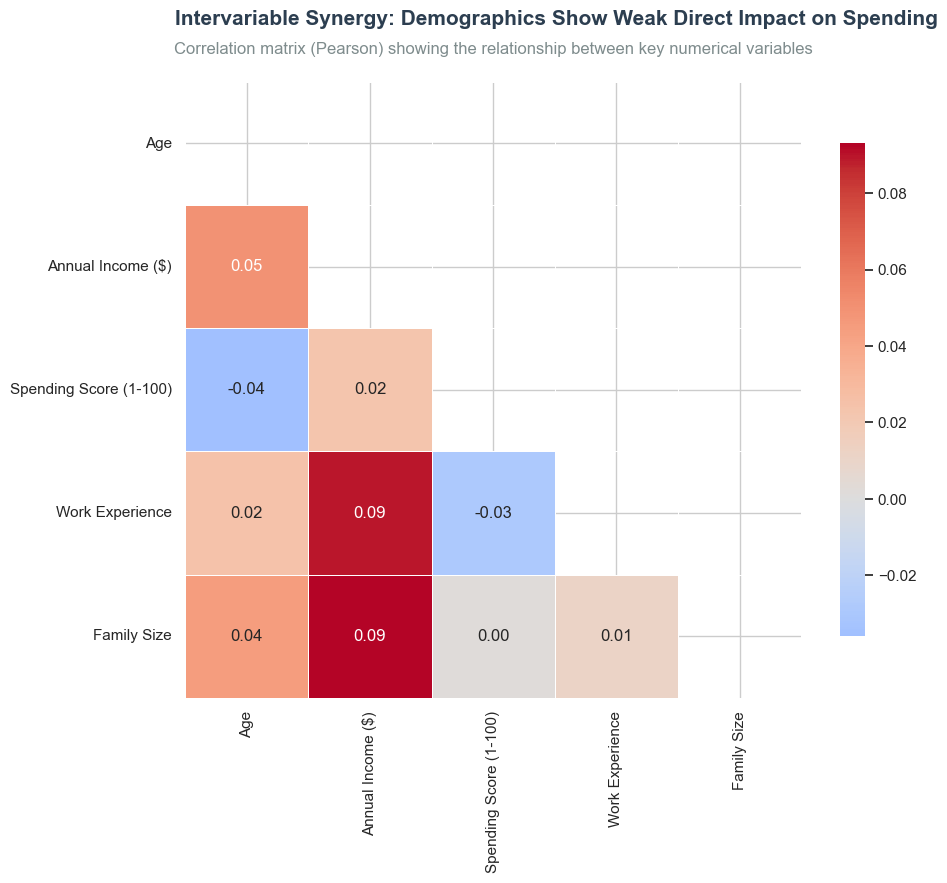

In [35]:
def plot_corr_matrix(ax, df):
    corr_matrix = df.drop(columns=['CustomerID']).corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))    
    sns.heatmap(corr_matrix,mask=mask, 
                annot=True, 
                fmt=".2f", 
                cmap='coolwarm',
                center=0,
                square=True, 
                linewidths=.5, 
                cbar_kws={"shrink": .8})
    plt.title('Correlation matrix (Pearson) showing the relationship between key numerical variables', 
          fontsize=12, color='#7f8c8d', pad=20)


fig, ax = plt.subplots(figsize=(10, 8))
plot_corr_matrix(ax, df)
plt.suptitle('Intervariable Synergy: Demographics Show Weak Direct Impact on Spending', 
             fontsize=15, fontweight='bold', color='#2c3e50', y=0.97)
plt.show()

### Dashboard

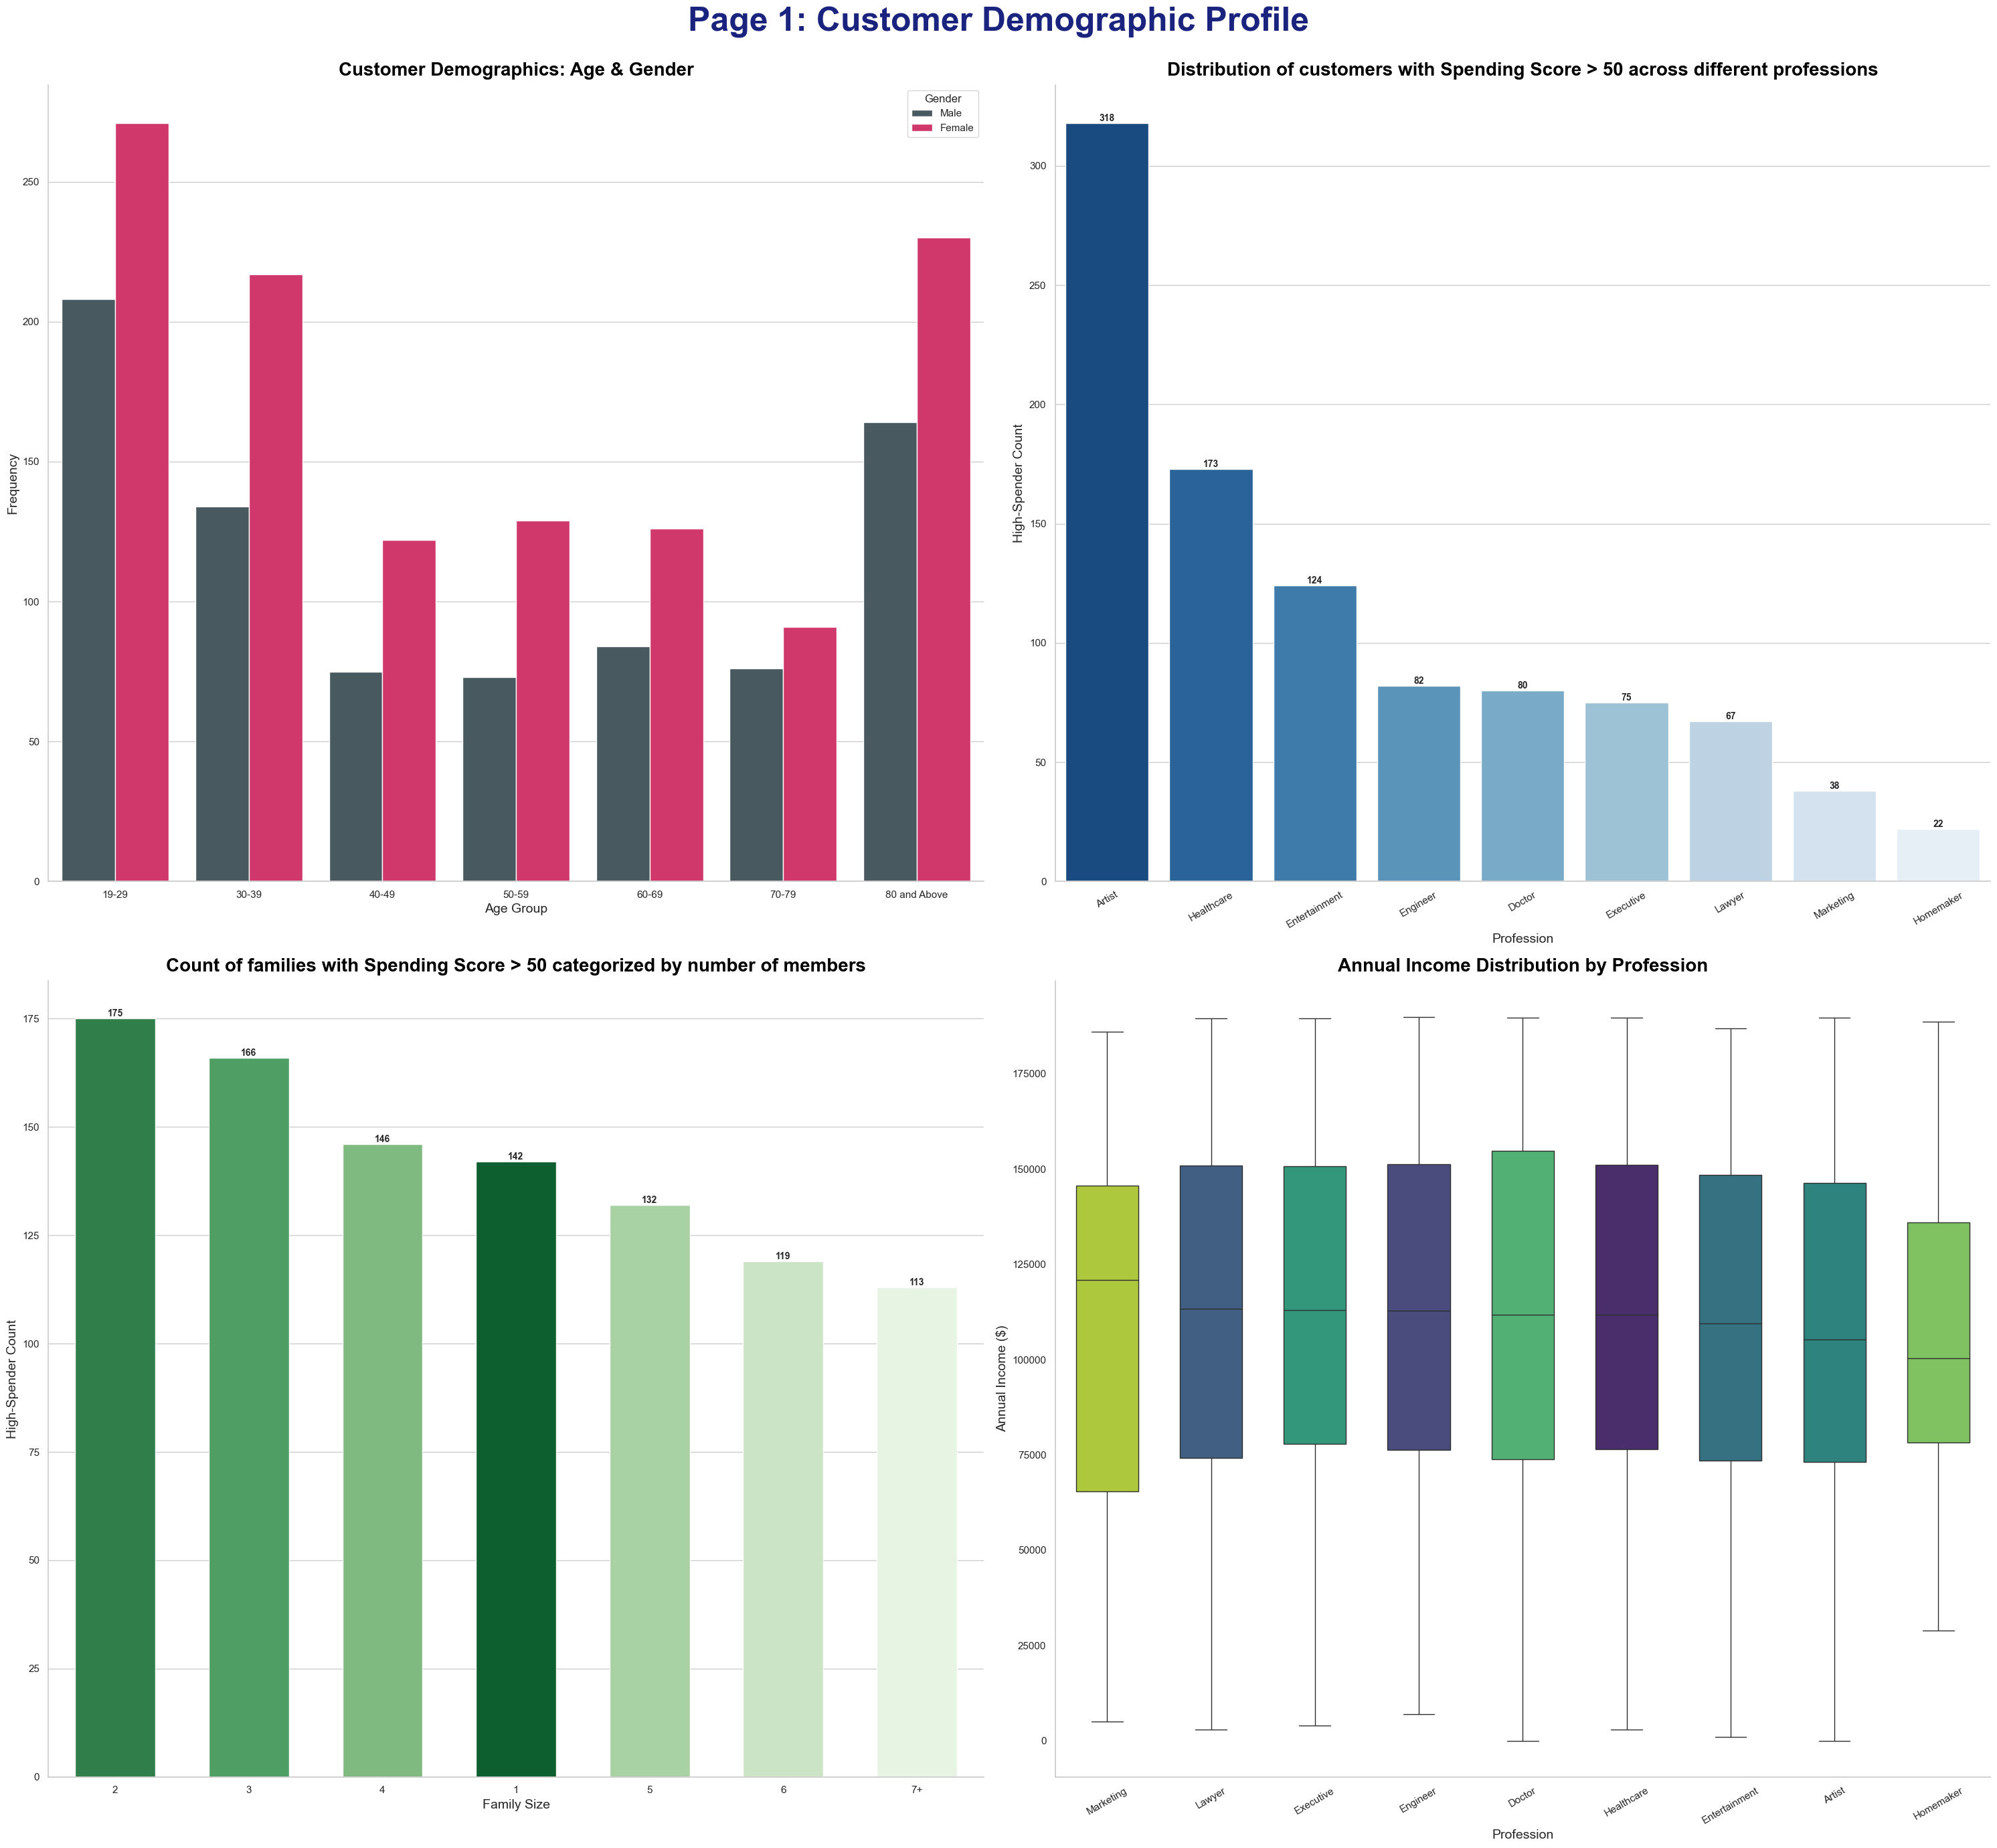

In [47]:
fig1, axes1 = plt.subplots(2, 2, figsize=(30, 30))

plot_demographics(axes1[0,0], df, 20, 'black')
plot_professions(axes1[0,1], df, 20, 'black')
plot_family_size(axes1[1,0], df, 20, 'black')
plot_income_dist(axes1[1,1], df, 20, 'black')


plt.suptitle('Page 1: Customer Demographic Profile',
             fontsize=36, fontweight='bold', y=0.95, color='#1a237e')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])


# plt.savefig('Strategic Dashboard - Page 1.png', dpi=300, bbox_inches='tight')
plt.show()

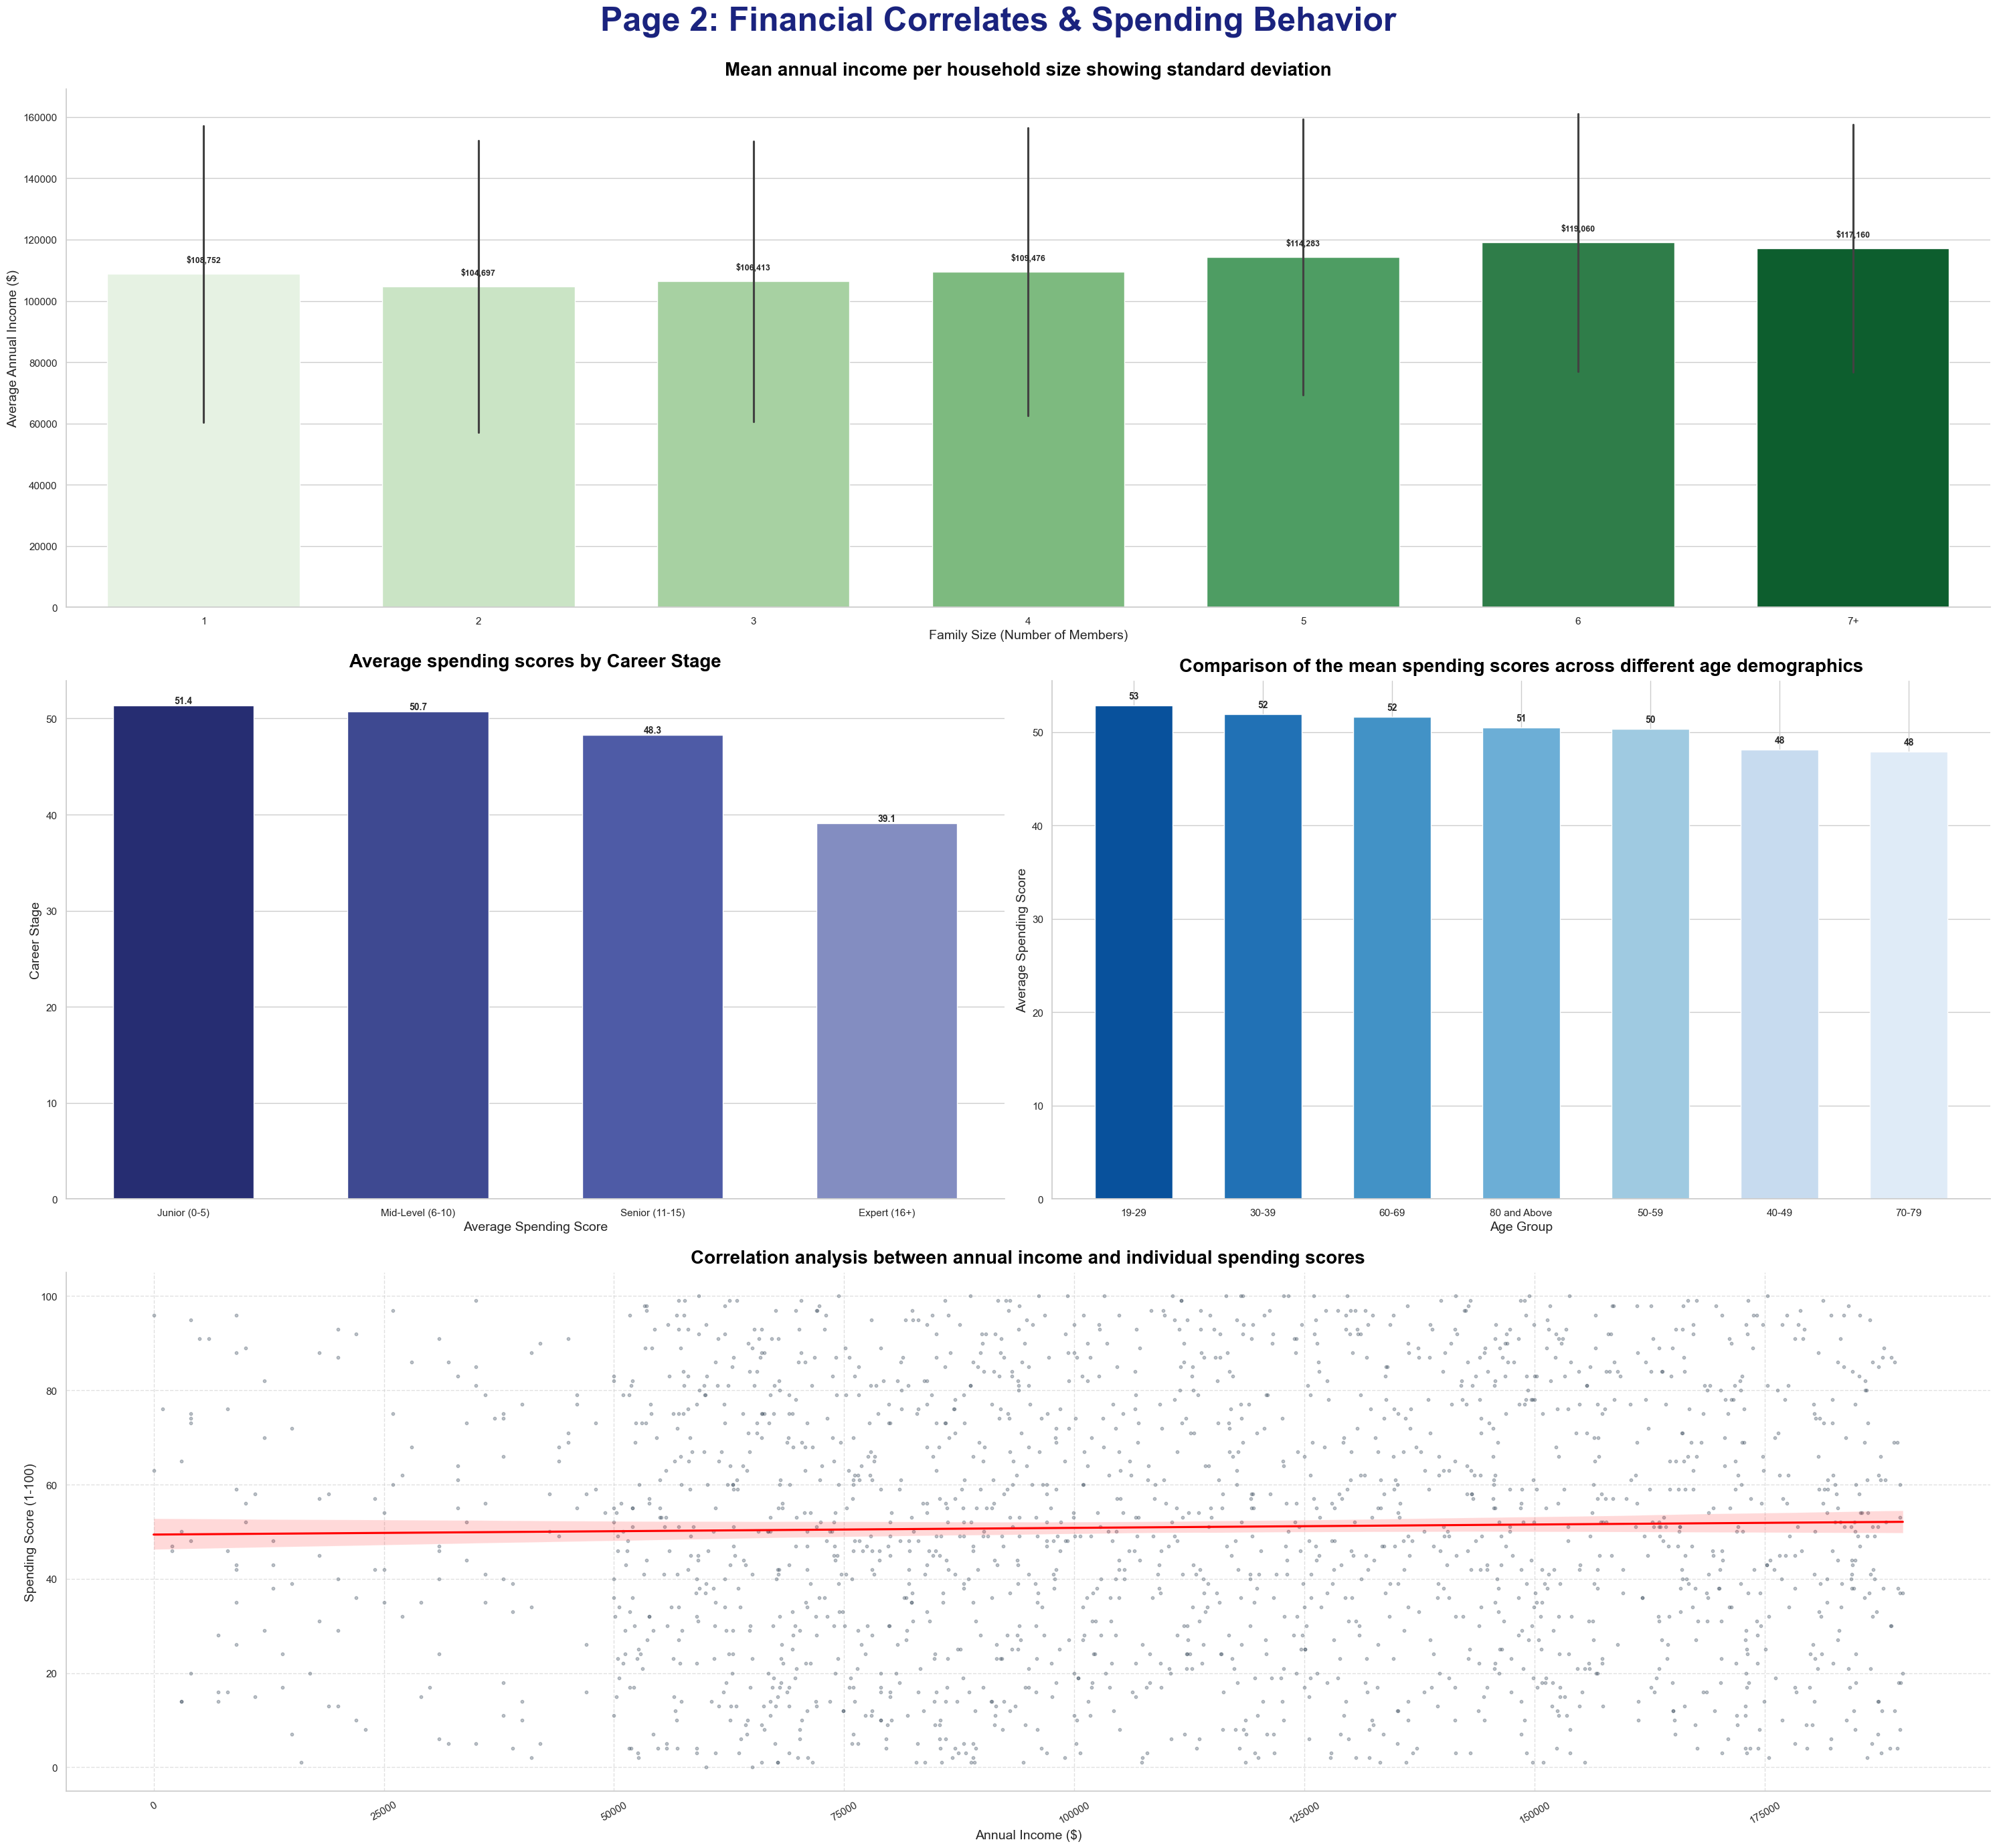

In [52]:
fig2 = plt.figure(figsize=(30, 30))

ax1 = plt.subplot2grid((3,2), (0,0), colspan=2)
ax2 = plt.subplot2grid((3,2), (1,0))
ax3 = plt.subplot2grid((3,2), (1,1))
ax4 = plt.subplot2grid((3,2), (2,0), colspan=2)

plot_family_income_trend(ax1, df, 20, 'black')
plot_experience_spending(ax2, df, 20, 'black')
plot_avg_spending(ax3, df, 20, 'black')
plot_corr_analysis(ax4, df, 20, 'black')

plt.suptitle('Page 2: Financial Correlates & Spending Behavior',
             fontsize=36, fontweight='bold', y=0.95, color='#1a237e')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# plt.savefig('Strategic Dashboard - Page 2.png', dpi=300, bbox_inches='tight')
plt.show()